<a href="https://colab.research.google.com/github/Joyslin-2006/PRODIGY_ML_03/blob/main/HomepricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as numpy
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [ ]:

test_data = pd.read_csv('test.csv')

In [ ]:
train_data = pd.read_csv('train.csv')

In [ ]:
for column in train_data.columns:
  if train_data[column].dtype== "object":
    train_data[column].fillna(train_data[column].mode()[0], inplace=True)
    if column in test_data.columns:
      test_data[column].fillna(test_data[column].mode() [0], inplace=True)
    else:
      train_data[column].fillna(train_data[column].mean(), inplace=True)
      if column in test_data.columns:
        test_data[column].fillna(test_data[column].mean(), inplace=True)

<ipython-input-16-db3950888c9c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[column].fillna(train_data[column].mode()[0], inplace=True)
<ipython-input-16-db3950888c9c>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
features = ['GrLivArea','BedroomAbvGr','FullBath','HalfBath','TotRmsAbvGrd']
x = train_data[features]
y = train_data['SalePrice']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model= LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [ ]:
!pip install matplotlip
import matplotlib.pyplot as plt



AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

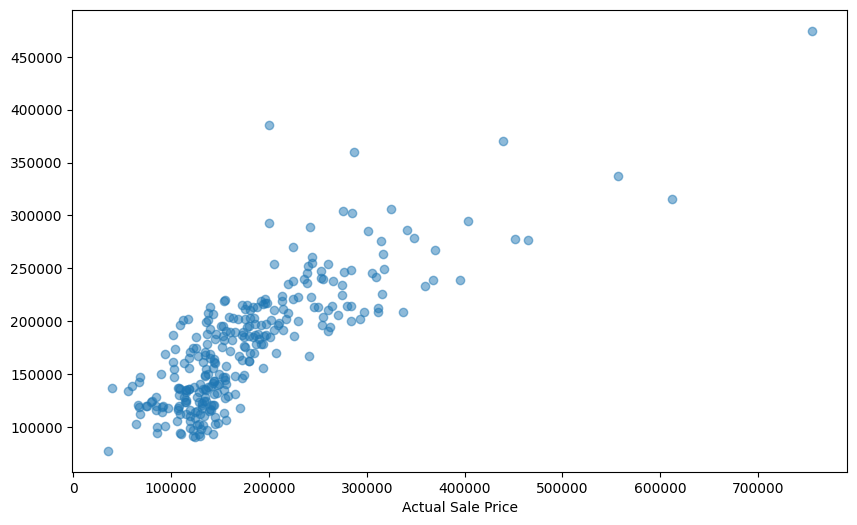

In [ ]:
y_pred = model.predict(x_val)
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel('Actual Sale Price')
plt.ylable('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

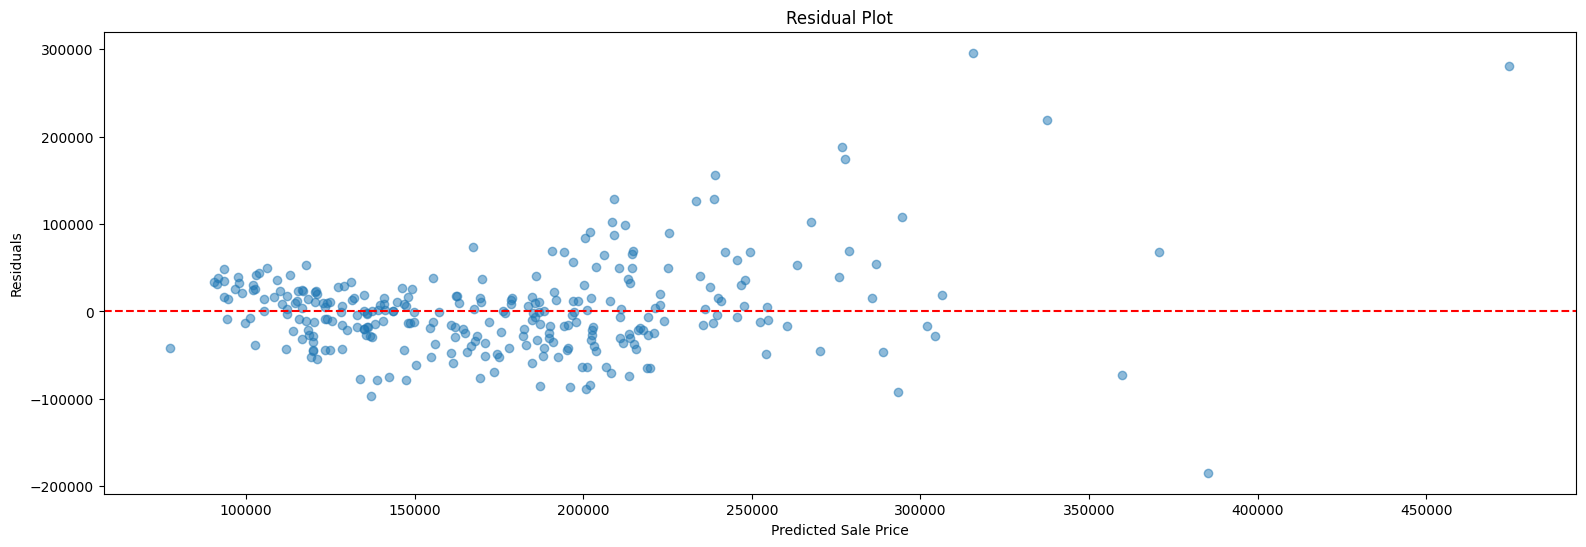

In [ ]:
residuals = y_val - y_pred
plt.figure(figsize=(19, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

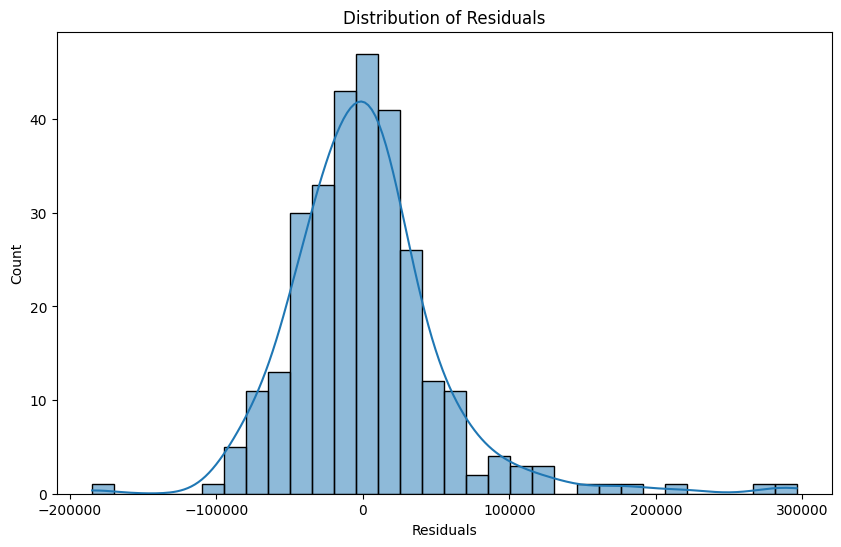

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()

<Figure size 1200x800 with 0 Axes>

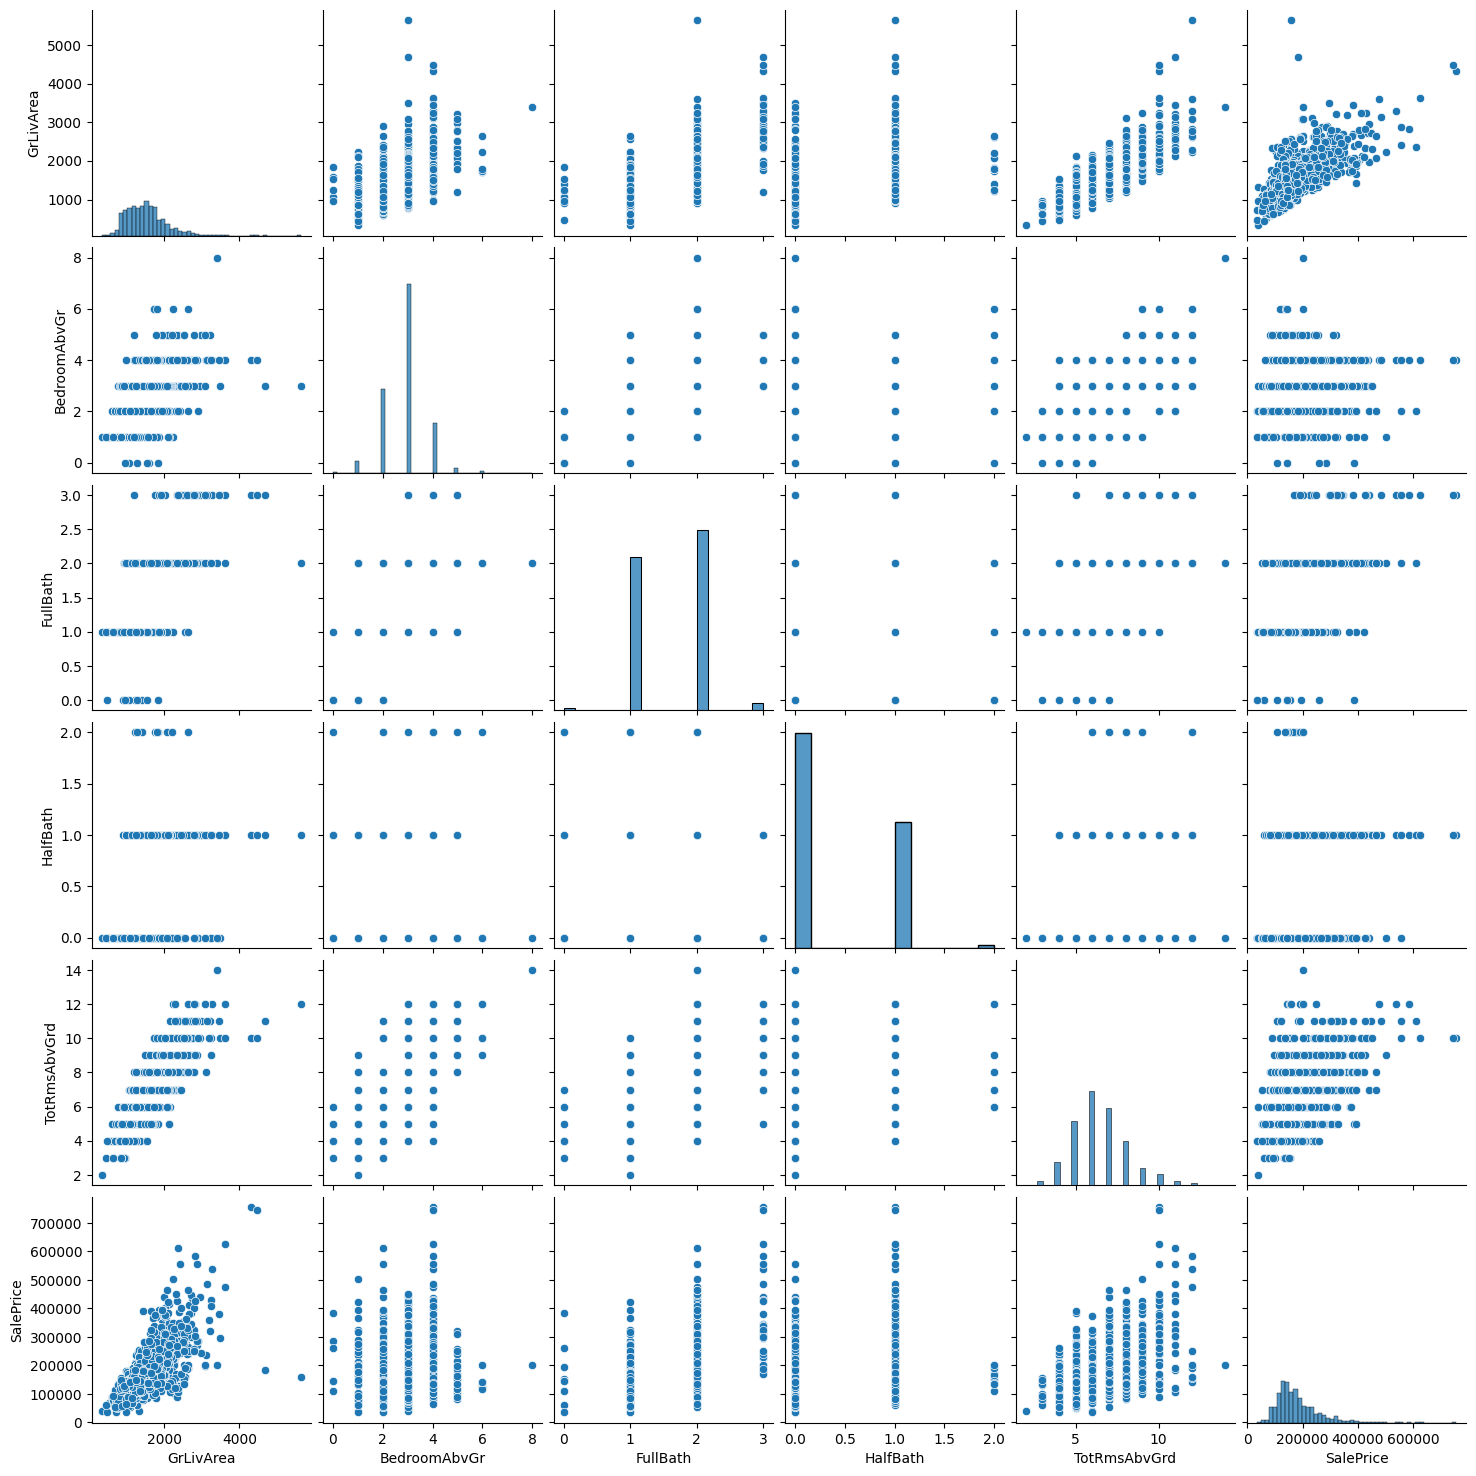

In [ ]:
plt.figure(figsize=(12,8))
sns.pairplot(train_data[features + ['SalePrice']])
plt.show()

In [ ]:
example = pd.DataFrame({
    'GrLivArea' : [2000],
    'BedroomAbvGr': [3],
    'FullBath': [2],
    'HalfBath': [1],
    'TotRmsAbvGrd':[7]
})
example_prediction = model.predict(example)
print(f'Example Prediction: ${example_prediction[0]:,.2f}')
x_test = test_data[features]
test_predictions = model.predict(x_test)

submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': test_predictions})
submission.to_csv('submission.csv', index=False)

Example Prediction: $240,896.28
